##  CIFAR-10 DATASET

#### Φόρτωση των απαραίτητων βιβλιοθηκών 
για τη δημιουργία ενός πλαισίου για την υλοποίηση ενός αγωγού μηχανικής μάθησης για την ταξινόμηση του συνόλου δεδομένων CIFAR-10 χρησιμοποιώντας Μηχανές Διανυσμάτων Υποστήριξης (SVM).

In [1]:
import numpy as np #numerical operations and handling arrays
from tensorflow.keras.datasets import cifar10
from sklearn.svm import SVC #for support vector Classification.
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay #evaluate performance
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt #visualizing data/results

#### Φόρτωση του συνόλου δεδομένων CIFAR-10 και εμφάνιση των δεδομένων για τον έλεγχο σωστής φόρτωσης των δεδομένων. 
Εξαγόμενο αποτέλεσμα: 
- **Training data shape**: (60000, 28, 28) (60000,), Αυτό υποδεικνύει ότι το σύνολο δεδομένων εκπαίδευσης αποτελείται από 60000 εικόνες μεγέθους 28*28, όπως ήταν αναμενόμενο και 60000 ετικέτες, όπου η καθεμία αντιστοιχεί σε μία εικόνα. 
- **Test data shape**: (10000, 28, 28) (10000,), Αυτό υποδεικνύει ότι το σύνολο δεδομένων δοκιμών αποτελείται από 10000 εικόνες μεγέθους 28*28 και 10000 ετικέτες, όπου η καθεμία αντιστοιχεί σε μία εικόνα. 

In [2]:
# Load cifar-10 dataset from Keras
(train_data, train_labels), (test_data, test_labels) = cifar10.load_data()


# Display shapes of the datasets
print("Training data shape:", train_data.shape, train_labels.shape)
print("Test data shape:", test_data.shape, test_labels.shape)

Training data shape: (50000, 32, 32, 3) (50000, 1)
Test data shape: (10000, 32, 32, 3) (10000, 1)


Ορισμός των ονομάτων των προϋπάρχουσων κλάσεων

In [3]:
class_names = [
    "Airplane", "Automobile", "Bird", "Cat", "Deer",
    "Dog", "Frog", "Horse", "Ship", "Truck"
]

### Οπτικοποίηση δεδομένων
Πραγματοποιείται **οπτικοποίηση** κάποιων εικόνων του συνόλου δεδομένων εκπαίδευσης. Αυτός ο κώδικας επιλέγει τυχαία 9 εικόνες RBG από το σύνολο test dataset CIFAR-10 και τις εμφανίζει σε ένα πλέγμα 3×3 με τις πραγματικές τους ετικέτες ως τίτλους/ ετικέτες

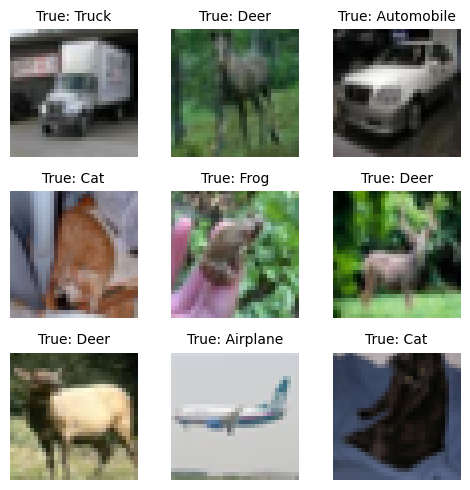

In [4]:
# Randomly sample some images from the test dataset
np.random.seed(42)  # For reproducibility
number_of_samples = 9  # Number of images to display
random_samples = np.random.randint(0, test_data.shape[0], size=(number_of_samples,))

# These lines extract the randomly selected images and their labels based on the randomly generated indices.
random_test_images = test_data[random_samples]
random_test_labels = test_labels[random_samples]


# Create a subplot grid
fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(5, 5))
for i, axi in enumerate(ax.flat):
    axi.imshow(random_test_images[i])  # Display the image in color 
    true_label = class_names[random_test_labels[i][0]]  # Convert label index to class name
    axi.axis("off")  # Turn off axis
    axi.set_title(f"True: {true_label}", fontsize=10)  # Show the true class name
plt.tight_layout()
plt.show()


Μετατροπή των εικόνων (και από τα δύο σύνολα δεδομένων) από 3 διαστάσεις (32* 32*3) σε μονοδιάστατα διανύσματα μήκους 3072 στοιχείων. Αυτή η μετατροπή είναι απαραίτητη επειδή οι μηχανές διανυσμάτων υποστήριξης (SVM), αναμένουν τα δεδομένα εισόδου να έχουν τη μορφή διανυσμάτων και όχι πολυδιάστατων πινάκων

In [5]:
# Flatten the images from 38*38*3 to 3072
train_data_flattened = train_data.reshape(train_data.shape[0], -1)  # Flatten each image to a vector
test_data_flattened = test_data.reshape(test_data.shape[0], -1)  # Flatten each image to a vector

Εκτελείται **κανονικοποίηση** του συνόλου δεδομένων CIFAR-10 κλιμακώνοντας τις τιμές των εικονοστοιχείων από το εύρος [0, 255] στο [0, 1]. 
Ο στόχος της κανονικοποίησης είναι να αλλάξει τις τιμές των αριθμητικών στηλών στο σύνολο δεδομένων για να χρησιμοποιηθεί μια κοινή κλίμακα, χωρίς να παραμορφωθούν οι διαφορές στο εύρος τιμών ή να χαθούν πληροφορίες. Διασφαλίζει ότι όλα τα χαρακτηριστικά (εντάσεις εικονοστοιχείων) συμβάλλουν εξίσου στο μοντέλο. Χωρίς κανονικοποίηση, χαρακτηριστικά με μεγαλύτερα εύρη θα μπορούσαν να κυριαρχούν σε άλλα, οδηγώντας σε κακή σύγκλιση ή χαμηλή απόδοση μοντέλου.
Τα σύνολα δεδομένων training και test έχουν την μορφή διανύσματος, (60000, 784) και (10000, 784) αντίστοιχα. Το κάθε στοιχείο αντιπροσωπεύεται ως διάνυσμα 784 χαρακτηριστικών.

In [6]:
# Normalize the data (scale pixel values to [0, 1])
train_data_flattened = train_data_flattened.astype('float32') / 255.0
test_data_flattened = test_data_flattened.astype('float32') / 255.0

# Print the range of values after normalization
print(f"Range of normalized training data: min = {train_data_flattened.min()}, max = {train_data_flattened.max()}")
print(f"Range of normalized test data: min = {test_data_flattened.min()}, max = {test_data_flattened.max()}")

print(f"Shape of training data after flattening: {train_data_flattened.shape}")
print(f"Shape of test data after flattening: {test_data_flattened.shape}")

Range of normalized training data: min = 0.0, max = 1.0
Range of normalized test data: min = 0.0, max = 1.0
Shape of training data after flattening: (50000, 3072)
Shape of test data after flattening: (10000, 3072)


Εφαρμόζεται **Principal Component Analysis (PCA)** και στα δύο σύνολα δεδομένων για να μειωθεί η διάστασή τους διατηρώντας παράλληλα το 90% (ή 95%) της διακύμανσης στα δεδομένα. Το 90% καθορίζει ότι ο αλγόριθμος PCA πρέπει να διατηρεί το 90% της διακύμανσης στο σύνολο δεδομένων και θα καθορίσει αυτόματα τον βέλτιστο αριθμό των principal components που απαιτούνται για την κάλυψη αυτού του ορίου διακύμανσης.  Έπειτα, πραγματοποιήθηκε εκτύπωση των δεδομένων και το εξαγόμενο αποτέλεσμα υποδεικνύει ότι έγινε όντως μείωση διάστασης.

In [7]:
# Apply PCA to reduce dimensionality, retaining 90% or 95% of the variance
pca = PCA(n_components=0.90)
train_data_pca = pca.fit_transform(train_data_flattened)
test_data_pca = pca.transform(test_data_flattened)

print(f"Shape of training data after PCA: {train_data_pca.shape}")
print(f"Shape of test data after PCA: {test_data_pca.shape}")


Shape of training data after PCA: (50000, 99)
Shape of test data after PCA: (10000, 99)


#### Δημιουργία του μοντέλου SVM
Σε αυτό το σημείο, ο κώδικας εκπαιδεύει έναν ταξινομητή Support Vector Machine (SVM) χρησιμοποιώντας έναν  πυρήνα (σε αυτή την περίπτωση γραμμικό – linear)  στα δεδομένα εκπαίδευσης που έχουν μετασχηματιστεί από PCA. Οι πυρήνες επιλέγονται βάσει της πολυπλοκότητας του εκάστοτε προβλήματος ταξινόμησης που χρειάζεται να λυθεί, και ανάλογα με τον πυρήνα, χρειάζονται και οι απαραίτητες **υπερπαράμετροι**. Στην περίπτωση του SVM, μία από τις βασικές υπερπαράμετροι είναι η **C** (παράμετρος Regularization). Η παράμετρος C βοηθά στην μεγιστοποίηση του περιθωρίου μεταξύ του ορίου απόφασης (διαχωρίζοντας υπερεπίπεδο) και των σημείων δεδομένων, και στην ελαχιστοποίηση σφαλμάτων ταξινόμησης (λανθασμένη ταξινόμηση παραδειγμάτων εκπαίδευσης). 
 - **Υψηλότερη τιμή C** δίνει μεγαλύτερη έμφαση στην ελαχιστοποίηση των σφαλμάτων ταξινόμησης, γεγονός που μπορεί να οδηγήσει σε υπερβολική προσαρμογή (το μοντέλο προσπαθεί να ταξινομήσει τέλεια τα δεδομένα εκπαίδευσης). 
 - **Χαμηλότερη τιμή C** επιτρέπει στο μοντέλο να έχει μεγαλύτερο περιθώριο, αποδέχεται ορισμένα σφάλματα ταξινόμησης, αλλά δυνητικά βελτιώνει τη γενίκευση. Μια πολύ υψηλή τιμή, όπου το μοντέλο εστιάζει σε μεγάλο βαθμό στην ελαχιστοποίηση των σφαλμάτων ταξινόμησης, τα οποία θα μπορούσαν να οδηγήσουν σε υπερβολική προσαρμογή.
  - **Degree /βαθμός πολυωνύμου** καθορίζει την υψηλότερη ισχύ του πολυωνύμου. Για παράδειγμα, αν degree=2, ο πυρήνας θα εξετάσει τις τετραγωνικές αλληλεπιδράσεις μεταξύ των χαρακτηριστικών. Η προσαρμογή αυτής της παραμέτρου επιτρέπει τον έλεγχο για το πόσο πολύπλοκο γίνεται το όριο απόφασης μεταξύ των κλάσεων. Oι  χαμηλότεροι βαθμοί (π.χ. 2) αποδίδουν γενικά χαμηλότερες ακρίβειες από τον βαθμό 3, που εξισορροπεί την πολυπλοκότητα και την απόδοση.  Οι υψηλότεροι βαθμοί (όπως ο 4) δείχνουν ελαφρώς μειωμένη ακρίβεια δοκιμής σε σύγκριση με τον βαθμό 3, λόγω υπερβολικής προσαρμογής. Ο χρόνος αυξάνεται με υψηλότερους βαθμούς, καθώς οι πολυωνυμικοί υπολογισμοί μεγαλώνουν σε πολυπλοκότητα.
 - **Gamma**  καθορίζει την επίδραση μεμονωμένων παραδειγμάτων εκπαίδευσης.Οι υψηλές τιμές gamma καθιστούν το όριο απόφασης πολύ ευαίσθητο σε μικρές διακυμάνσεις στα δεδομένα (υπερπροσαρμογή). 

In [8]:
#create the SVM model
svm = SVC(probability=False, kernel='linear', C=1)  
svm.fit(train_data_pca, train_labels)


C:\Users\Χριστινα\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\utils\validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVC(C=1, kernel='linear')

In [9]:
# Create the SVM model with polynomyal kernel
#svm = SVC(probability=False, kernel='poly', C=10, degree=3)

# Fit the model to the PCA-transformed training data
#svm.fit(train_data_pca, train_labels)

In [10]:
# Create the SVM model with RBF kernel
#svm = SVC(probability=False, kernel='rbf', C=10, gamma='scale')

# Fit the model to the PCA-transformed training data
#svm.fit(train_data_pca, train_labels)

In [11]:
# Create the SVM model with sigmoid kernel
#svm = SVC(probability=False, kernel='sigmoid', C=0.1)

# Fit the model to the PCA-transformed training data
#svm.fit(train_data_pca, train_labels)

Το μοντέλο προβλέπει τις ετικέτες δεδομένων εκπαίδευσης χρησιμοποιώντας το εκπαιδευμένο μοντέλο SVM και αξιολογεί την ακρίβεια της εκπαίδευσης (training). Η ακρίβεια εκπαίδευσης (training accuracy) θα πρέπει γενικά να είναι λίγο μεγαλύτερη από την ακρίβεια της δοκιμής (test accuracy), επειδή το μοντέλο είναι άμεσα βελτιστοποιημένο για να αποδίδει καλά στα δεδομένα εκπαίδευσης (training data) και λόγω των προκλήσεων της γενίκευσης σε  δεδομένα που δεν έχει ελέγξει ακόμα ο αλγόριθμος. 
- Όταν η ακρίβεια της εκπαίδευσης είναι πολύ μεγαλύτερη από αυτήν της δοκιμής, τότε συμβαίνει το φαινόμενο της **υπερεκπαίδευσης**. 
- Όταν η ακρίβεια της εκπαίδευσης είναι πολύ μικρή, όπως και αυτή της δοκιμής, τότε συμβαίνει το φαινόμενο της **υποεκπαίδευσης**.    

In [12]:
#training acc has to be a  little be higher than test acc
train_predictions = svm.predict(train_data_pca) #The model predicts the training data labels using the trained SVM model

# Evaluate training accuracy
train_accuracy = accuracy_score(train_labels, train_predictions) #Compares the predicted labels (train_predictions) to the true (train_labels) and calculates the accuracy
print(f"Training Accuracy: {train_accuracy:.4f}")

Training Accuracy: 0.4204


Με την ακρίβεια δοκιμής, φαίνεται πόσο καλά έχει εκπαιδευτεί το μοντέλο σε  νέα δεδομένα,  καθώς εδώ υπάρχει και η πρόκληση τα νέα δεδομένα να μην  είναι τόσο ευανάγνωστα (γενικά να υπάρχει θόρυβος), και ελέγχεται σε τι ποσοστό οι ετικέτες έχουν αντιστοιχηθεί σωστά στις εικόνες.

In [13]:
# Make predictions on the test set
test_predictions = svm.predict(test_data_pca)

# Evaluate the model
accuracy = accuracy_score(test_labels, test_predictions)
print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.4080


Το ακόλουθο τμήμα κώδικα δημιουργεί και οπτικοποιεί τον **πίνακα σύγχυσης**, ο οποίος παρέχει μια λεπτομερή ανάλυση της απόδοσης ταξινόμησης του μοντέλου σε όλες τις κατηγορίες (κλάσεις). Οι γραμμές του πίνακα αντιστοιχούν στις αληθινές ετικέτες, ενώ οι στήλες αντιστοιχούν στις προβλεπόμενες ετικέτες. Διαγώνια βρίσκονται τα στοιχεία που προβλέφθηκαν και ήταν τελικά σωστά, δηλαδή η ετικέτα κάθε εικόνας ανταποκρίθηκε σωστά στο περιεχόμενό της. 

<Figure size 1000x1000 with 0 Axes>

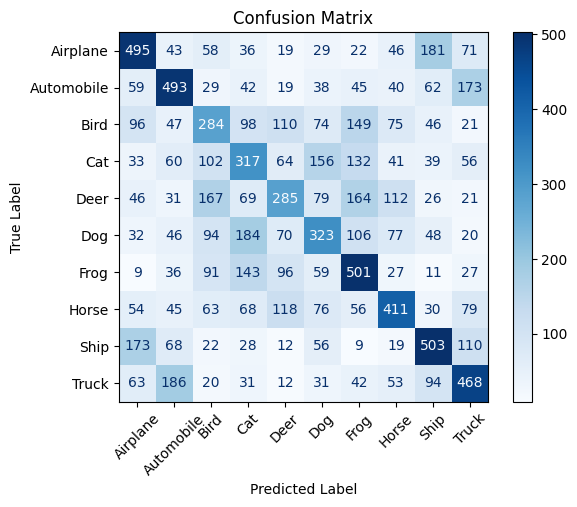

In [14]:
# Confusion Matrix
conf_matrix = confusion_matrix(test_labels, test_predictions)

# Display the confusion matrix with class names
plt.figure(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=class_names) #for cifar10
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title("Confusion Matrix")
plt.show()